# Assignment 2. Option 2

## Dataset Exploration

In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [45]:
from pathlib import Path
from src.dataset import VoxConverseDataset, make_collate_fn
from torch.utils.data import DataLoader

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 10

In [46]:
dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dataloader_dev = DataLoader(
  dataset_dev,
  shuffle=False,
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  shuffle=True,
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

### A Voice Activity Detection (VAD) model using a supervised neural network approach

<div align="center"><img src="img/vad.png" height="800"></div>

torch.Size([1, 6838])
speech fraction: 0.9154723882675171


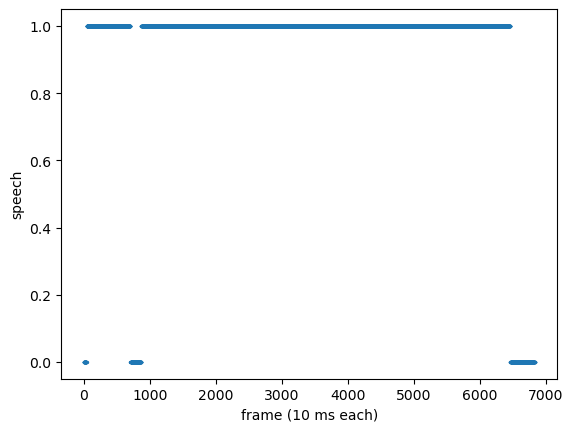

In [47]:
import torch
from torch import nn
import matplotlib.pyplot as plt

(waveform, labels, mask) = next(iter(dataloader_dev))

print(labels.shape)
print("speech fraction:", labels.float().mean().item())
y = labels[0].numpy()
x = range(len(y))

plt.scatter(x, y, s=2)
plt.xlabel("frame (10 ms each)")
plt.ylabel("speech")
plt.show()

In [48]:
import torchaudio.transforms as T
import torch.nn.functional as F
import warnings

warnings.filterwarnings("ignore", message="An output with one or more elements was resized")

class MelSpectrogramExtractor(nn.Module):
  def __init__(
      self,
      mel_bands: int = 32,
      sample_rate: int = 16000,
      hop_ms: float = 10.0,
      win_ms: float = 25.0,
      n_fft: int = 512,
      eps: float = 1e-6,
  ):
    super().__init__()
    self.mel_bands = mel_bands
    self.eps = eps
    self.hop_ms = hop_ms
    self.melspec = nn.Sequential(
      T.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        win_length=int(sample_rate * win_ms / 1000),
        hop_length=int(sample_rate * hop_ms / 1000),
        n_mels=mel_bands,
        normalized=True,
      )
    )

  def forward(self, X):
    mel = self.melspec(X) # type: ignore[attr-defined]
    mel = torch.log(mel + self.eps)
    mel = mel.transpose(1, 2)
    return mel

class VoiceActivityDetector(nn.Module):
  def __init__(
    self,
    device: str,
    spectrogram_layer: MelSpectrogramExtractor,
    subsample_size: int = 320,
  ):
    super().__init__()
    self.device = device
    self.spectrogram = spectrogram_layer
    self.subsample_size = subsample_size

    self.cnn = nn.Sequential(
      nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2),
      nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2),
      nn.Flatten(),
      nn.Linear(2048, 1)
    )

  def _chunk(self, mel, labels, mask):
    n_frames = min(mel.shape[1], labels.shape[1])
    mel, labels, mask = mel[:, :n_frames], labels[:, :n_frames], mask[:, :n_frames]

    chunk_size = int(self.subsample_size / self.spectrogram.hop_ms)
    padding = (chunk_size - n_frames % chunk_size) % chunk_size

    if padding:
      mel = F.pad(mel, (0, 0, 0, padding))
      labels = F.pad(labels, (0, padding))
      mask = F.pad(mask, (0, padding), value=False)

    n_chunks = mel.shape[1] // chunk_size
    mel = mel.reshape(mel.shape[0], n_chunks, chunk_size, mel.shape[2])

    labels = labels.reshape(labels.shape[0], n_chunks, chunk_size)
    labels = labels.sum(-1)
    labels = labels > chunk_size // 2

    mask = mask.reshape(mask.shape[0], n_chunks, chunk_size)
    mask = mask.any(-1)

    return mel, labels, mask

  def forward(self, X):
    (waveform, labels, mask) = X

    mel = self.spectrogram(waveform)

    (mel, labels, mask) = self._chunk(mel, labels, mask)

    B, n_chunks, H, W = mel.shape

    Y = mel.reshape(B * n_chunks, 1, H, W)
    Y = self.cnn(Y)
    Y = Y.reshape(B, n_chunks)#, -1)

    return Y, labels, mask

In [52]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score
)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
epochs = 3
lr = 1e-3

print(f"Device: {device}")

vad = VoiceActivityDetector(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(
    sample_rate=SAMPLE_RATE,
    hop_ms=HOP,
  )
)

def fmt_metrics(metrics, order=("acc", "P", "R", "F1")):
    return " | ".join(f"{k} {metrics[k].item():.3f}" for k in order)

def evaluate_vad(model, x, loss, metrics, opt=None, i=0):
  x = tuple(t.to(device) for t in x)

  pred, labels, mask = model(x)
  pred, labels = pred[mask], labels[mask]

  lvalue = loss(pred, labels.float())

  if opt:
    lvalue.backward()
    opt.step()
    opt.zero_grad()

  stats = metrics(torch.sigmoid(pred), labels.int())
  if i % 50 == 0 or i == 1:
    print(f"  batch {i:3d} | loss {lvalue.item():.4f} | " +
      " | ".join(f"{k} {v:.3f}" for k, v in stats.items()))

def train():
  vad.to(device)

  loss = nn.BCEWithLogitsLoss()
  opt = torch.optim.Adam(vad.parameters(), lr=lr)

  train_metrics = MetricCollection({
    "acc": BinaryAccuracy(),
    "P":   BinaryPrecision(),
    "R":   BinaryRecall(),
    "F1":  BinaryF1Score(),
  }).to(device)

  test_metrics = train_metrics.clone().to(device)

  for epoch in range(epochs):
    print(f"===== EPOCH {epoch + 1}/{epochs} - train =====")
    vad.train()
    for i, x in enumerate(dataloader_dev):
      evaluate_vad(vad, x, loss, train_metrics, opt, i + 1)

    print(f"train | {fmt_metrics(train_metrics.compute())}")
    train_metrics.reset()

    vad.eval()
    print(f"===== EPOCH {epoch + 1}/{epochs} - test =====")
    with torch.no_grad():
      for i, x in enumerate(dataloader_test):
        evaluate_vad(vad, x, loss, test_metrics, opt=None, i=i + 1)

    print(f"test  | {fmt_metrics(test_metrics.compute())}")
    test_metrics.reset()

train()

Device: mps
===== EPOCH 1/3 - train =====
  batch   1 | loss 1.0456 | F1 0.177 | P 1.000 | R 0.097 | acc 0.173
  batch  50 | loss 0.2176 | F1 0.968 | P 0.937 | R 1.000 | acc 0.937
  batch 100 | loss 0.0921 | F1 0.995 | P 0.994 | R 0.996 | acc 0.990
  batch 150 | loss 0.0389 | F1 0.999 | P 0.997 | R 1.000 | acc 0.997
  batch 200 | loss 0.0617 | F1 0.990 | P 0.984 | R 0.997 | acc 0.981
train | acc 0.928 | P 0.943 | R 0.982 | F1 0.962
===== EPOCH 1/3 - test =====
  batch   1 | loss 0.2318 | F1 0.948 | P 0.944 | R 0.952 | acc 0.905
  batch  50 | loss 0.1070 | F1 0.979 | P 0.998 | R 0.960 | acc 0.958
  batch 100 | loss 0.1384 | F1 0.975 | P 0.985 | R 0.966 | acc 0.952
  batch 150 | loss 0.1718 | F1 0.947 | P 0.910 | R 0.988 | acc 0.902
  batch 200 | loss 0.2265 | F1 0.936 | P 0.903 | R 0.971 | acc 0.893
test  | acc 0.906 | P 0.925 | R 0.973 | F1 0.949
===== EPOCH 2/3 - train =====
  batch   1 | loss 0.1897 | F1 0.958 | P 0.924 | R 0.995 | acc 0.921
  batch  50 | loss 0.2189 | F1 0.952 | P 0